In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Video_Games_Sales_as_at_22_Dec_2016.csv')

## UNDERSTAND THE RAW DATA!

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(16719, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [6]:
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [7]:
df.nunique()

Name               11562
Platform              31
Year_of_Release       39
Genre                 12
Publisher            581
NA_Sales             402
EU_Sales             307
JP_Sales             244
Other_Sales          155
Global_Sales         629
Critic_Score          82
Critic_Count         106
User_Score            96
User_Count           888
Developer           1696
Rating                 8
dtype: int64

In [8]:
df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

## Data Cleaning

In [9]:
df = df.dropna(axis=0, subset=['Name','Year_of_Release'])

In [10]:
df['Publisher'] = df['Publisher'].fillna('Unknown')

In [11]:
df['Year_of_Release'] = df['Year_of_Release'].astype(int)
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
df['User_Score'] = df['User_Score'] * 10
critic = df['Critic_Score'].unique()
user = df['User_Score'].unique()
year = df['Year_of_Release'].unique()
critic.sort()
user.sort()
year.sort()
critic, user, year

(array([13., 17., 19., 20., 21., 23., 24., 25., 26., 27., 28., 29., 30.,
        31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
        44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
        57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
        70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.,
        83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95.,
        96., 97., 98., nan]),
 array([ 0.,  2.,  3.,  5.,  6.,  7.,  9., 10., 11., 12., 13., 14., 15.,
        16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28.,
        29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
        42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54.,
        55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67.,
        68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80.,
        81., 82., 83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93.,
        94., 95., 96.

In [12]:
display(df.head())
display(df.isnull().sum())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,80.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,83.0,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,80.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8465
Critic_Count       8465
User_Score         8985
User_Count         8985
Developer          6541
Rating             6679
dtype: int64

In [13]:
df_ratings = df.dropna(subset=['Critic_Score', 'User_Score', 'Rating'])
df_ratings.shape

(6826, 16)

## Univariate EDA

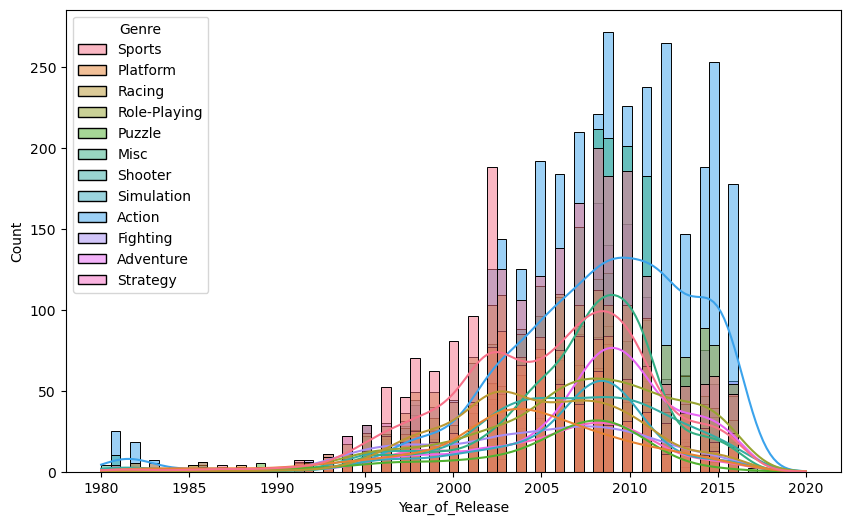

In [14]:
fig, ax = plt.subplots(figsize=(10,6))
sns.histplot(data=df,x='Year_of_Release', hue='Genre', kde=True)
plt.show()

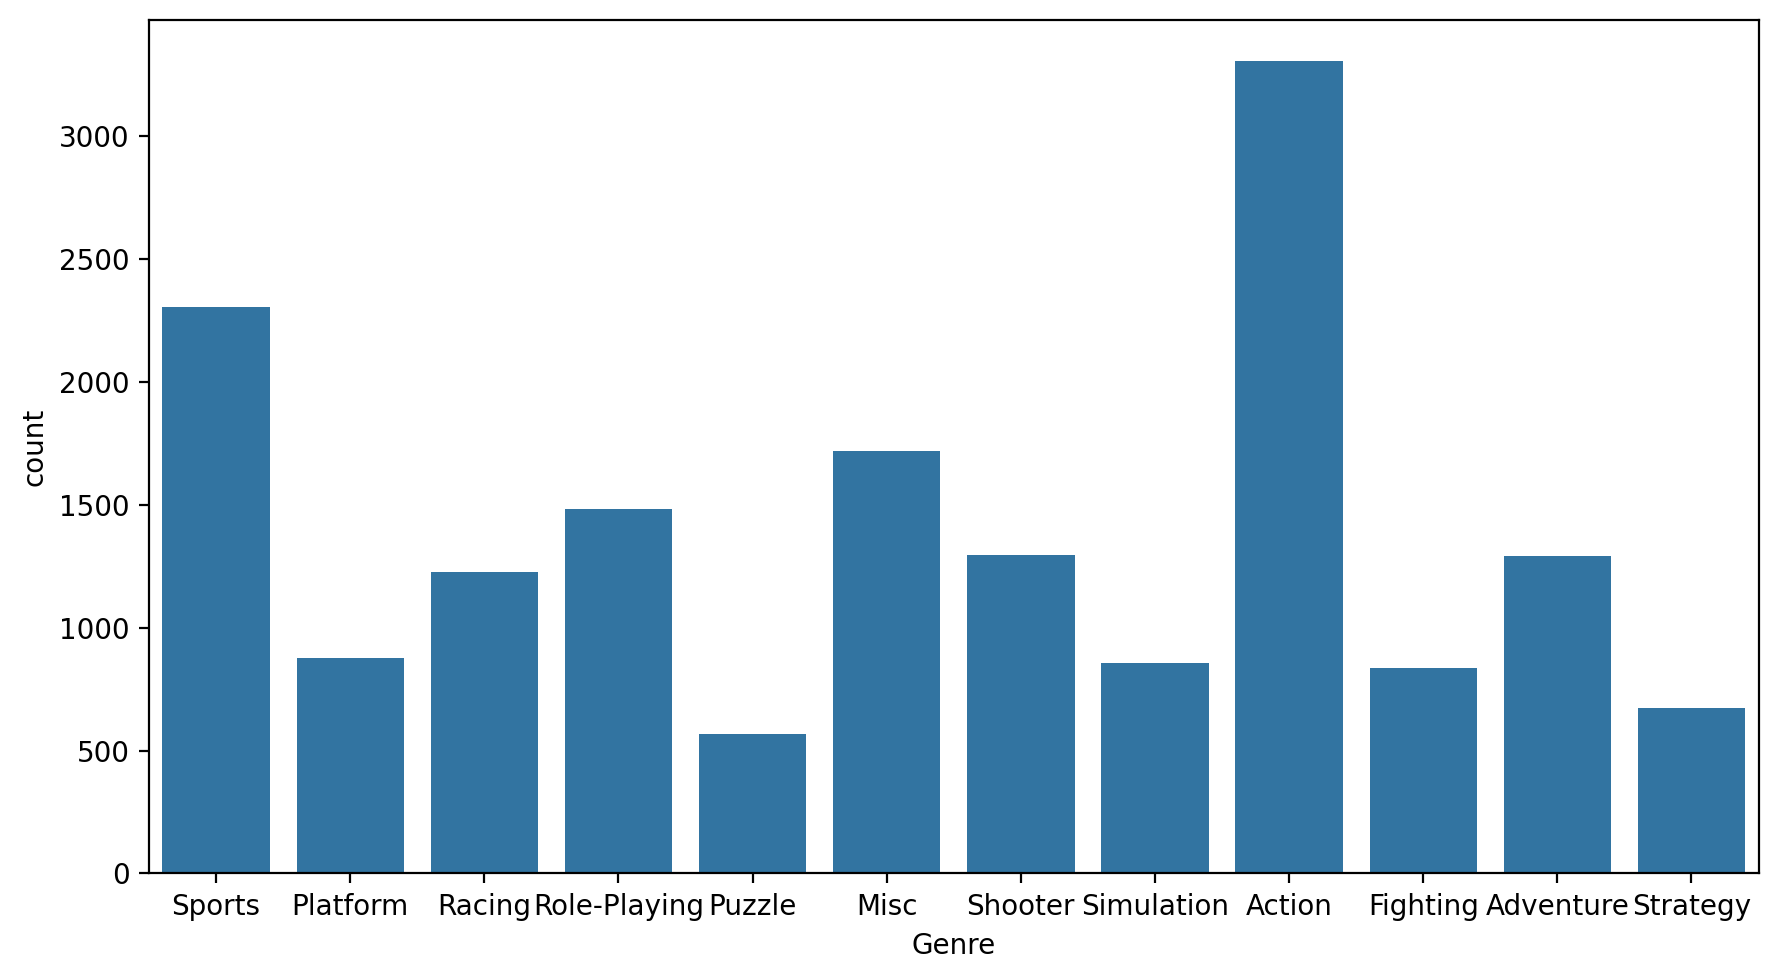

In [15]:
fix, ax = plt.subplots(figsize=(9,5), dpi=200)
sns.countplot(data=df, x='Genre')
plt.tight_layout()
plt.show()

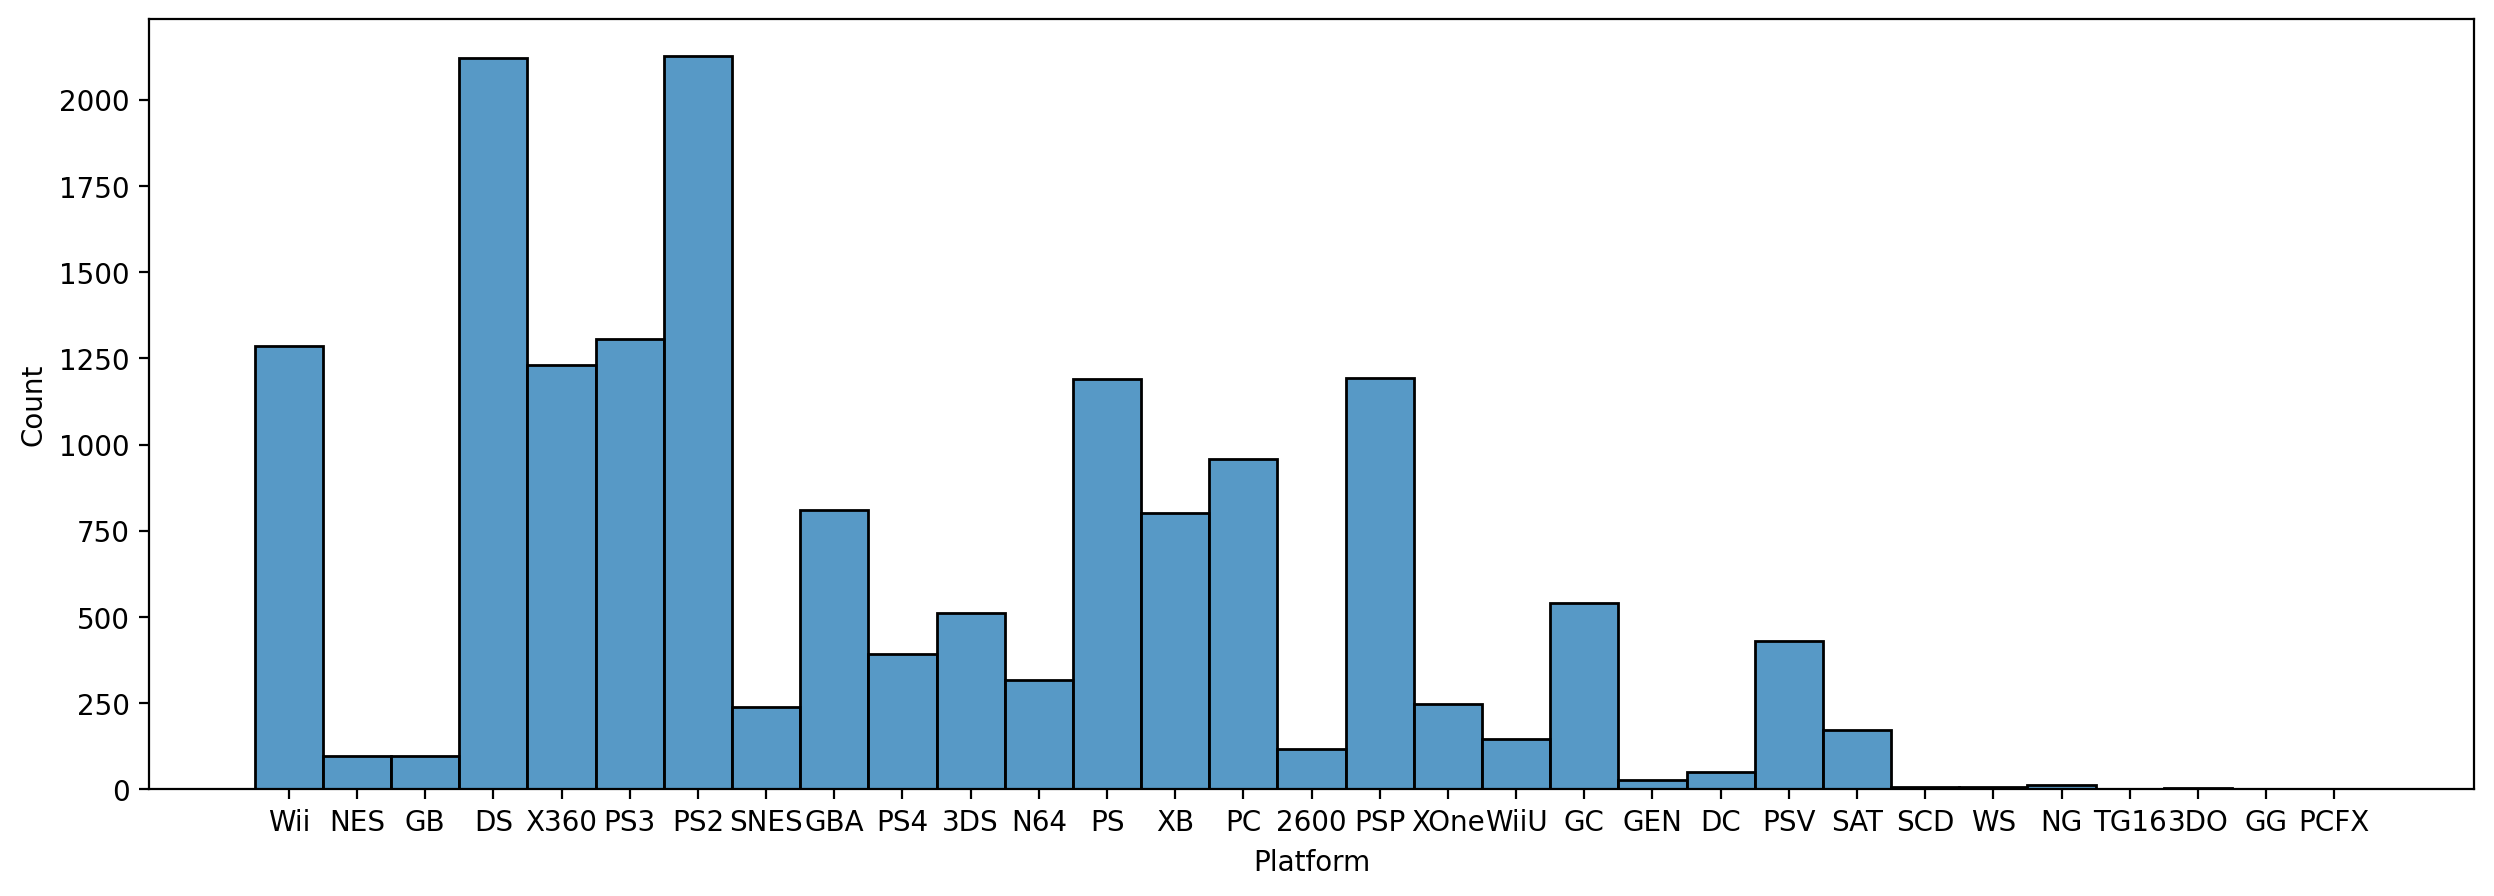

In [16]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Platform')
plt.show()

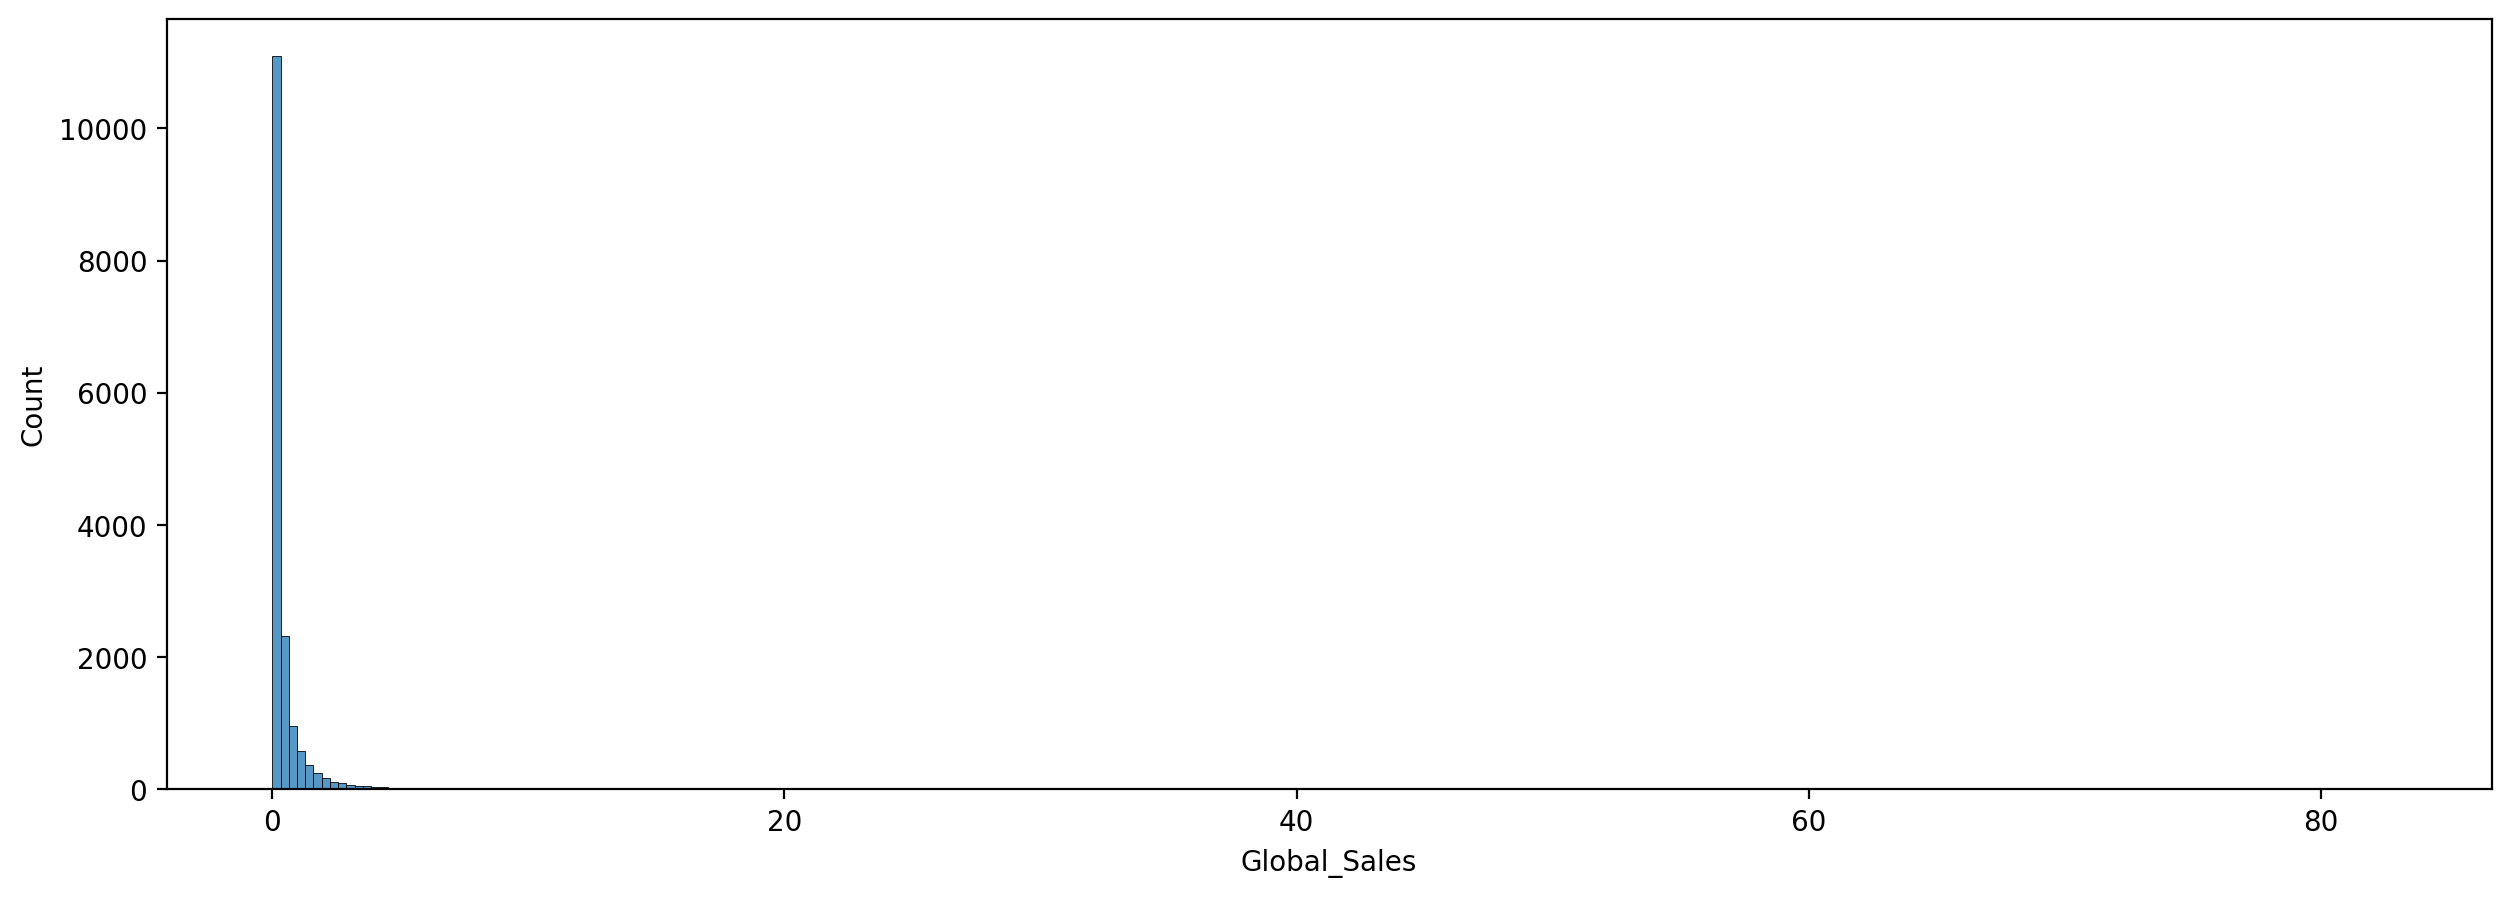


Percentage of titles that sold less than a million copies: 87.5182392996109


In [17]:
fix, ax = plt.subplots(figsize=(15,5), dpi=200)
sns.histplot(data=df, x='Global_Sales')
plt.show()
percentage = (df['Global_Sales'] < 1).sum() / len(df) * 100
print(f'\nPercentage of titles that sold less than a million copies: {percentage}')

The strong right skew of this distribution indicates that if we randomly select a game from the dataset, it is highly likely to have sold relatively few copies. A small number of blockbuster titles achieved exceptionally high sales, appearing as outliers and pulling the distribution to the right.

To quantify this observation, we calculated the percentage of games that sold fewer than one million copies. We found that 87.58% of all games fall into this category, confirming that commercial success is concentrated among a relatively small number of titles, while the majority of games achieved only modest sales.

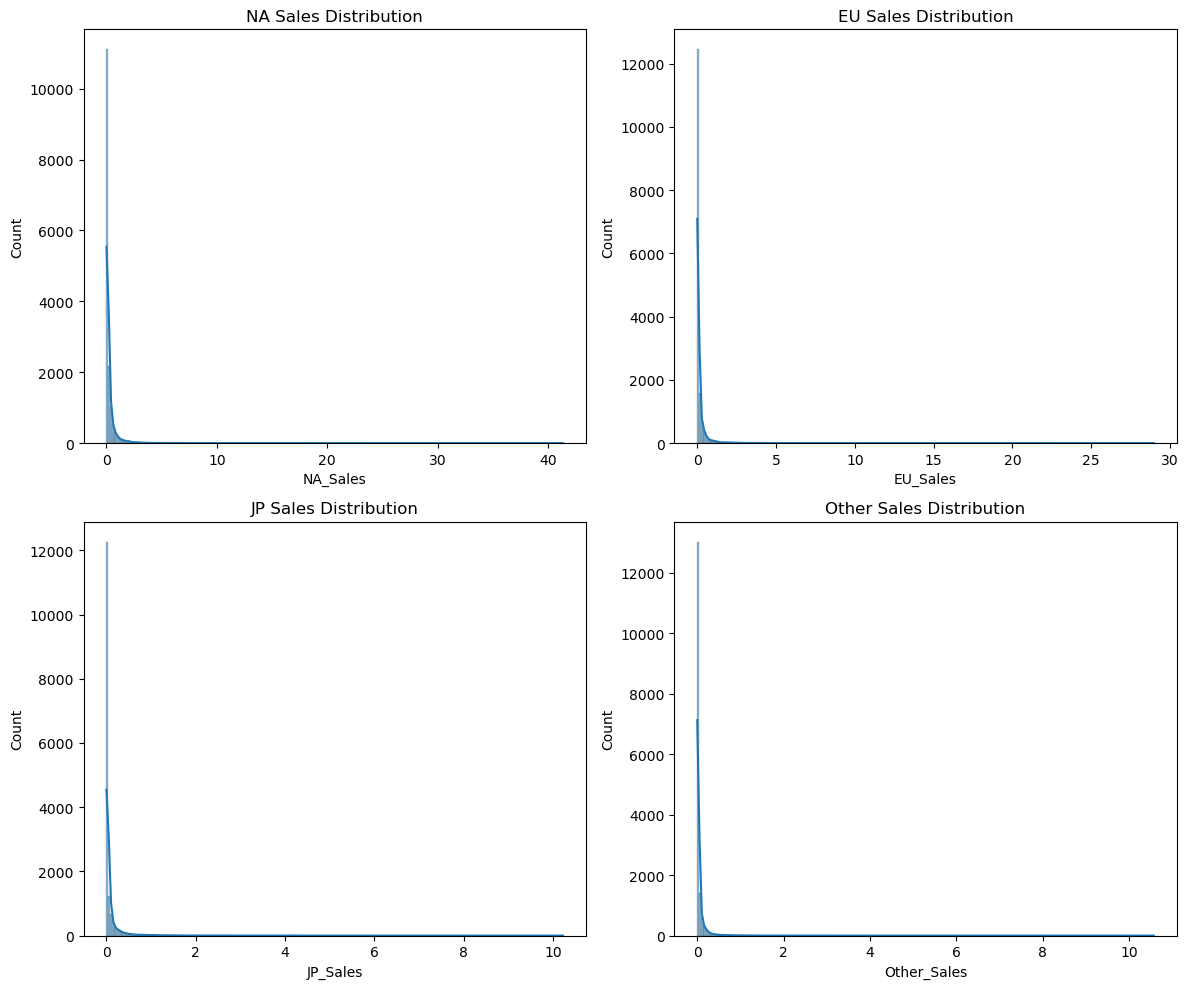

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(data=df, x='NA_Sales', ax=axes[0,0], kde=True)
axes[0,0].set_title('NA Sales Distribution')

sns.histplot(data=df, x='EU_Sales', ax=axes[0,1], kde=True)
axes[0,1].set_title('EU Sales Distribution')

sns.histplot(data=df, x='JP_Sales', ax=axes[1,0], kde=True)
axes[1,0].set_title('JP Sales Distribution')

sns.histplot(data=df, x='Other_Sales', ax=axes[1,1], kde=True)
axes[1,1].set_title('Other Sales Distribution')

plt.tight_layout()
plt.show()

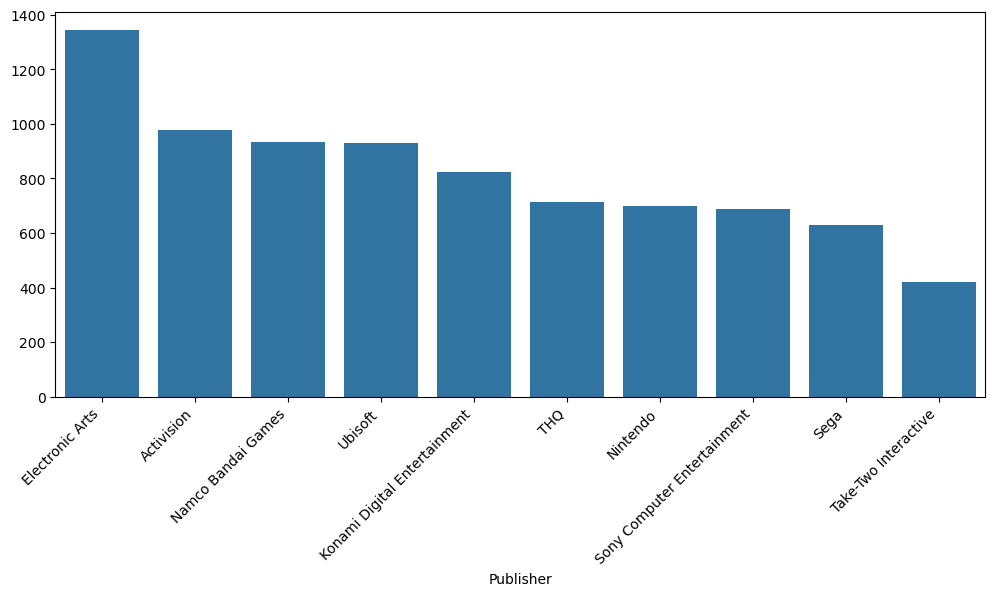

In [19]:
top10_publishers = df['Publisher'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12,5))
sns.barplot(x=top10_publishers.index, y=top10_publishers.values)
plt.xticks(rotation=45, ha='right')
plt.show()

## Bivariate sales focused

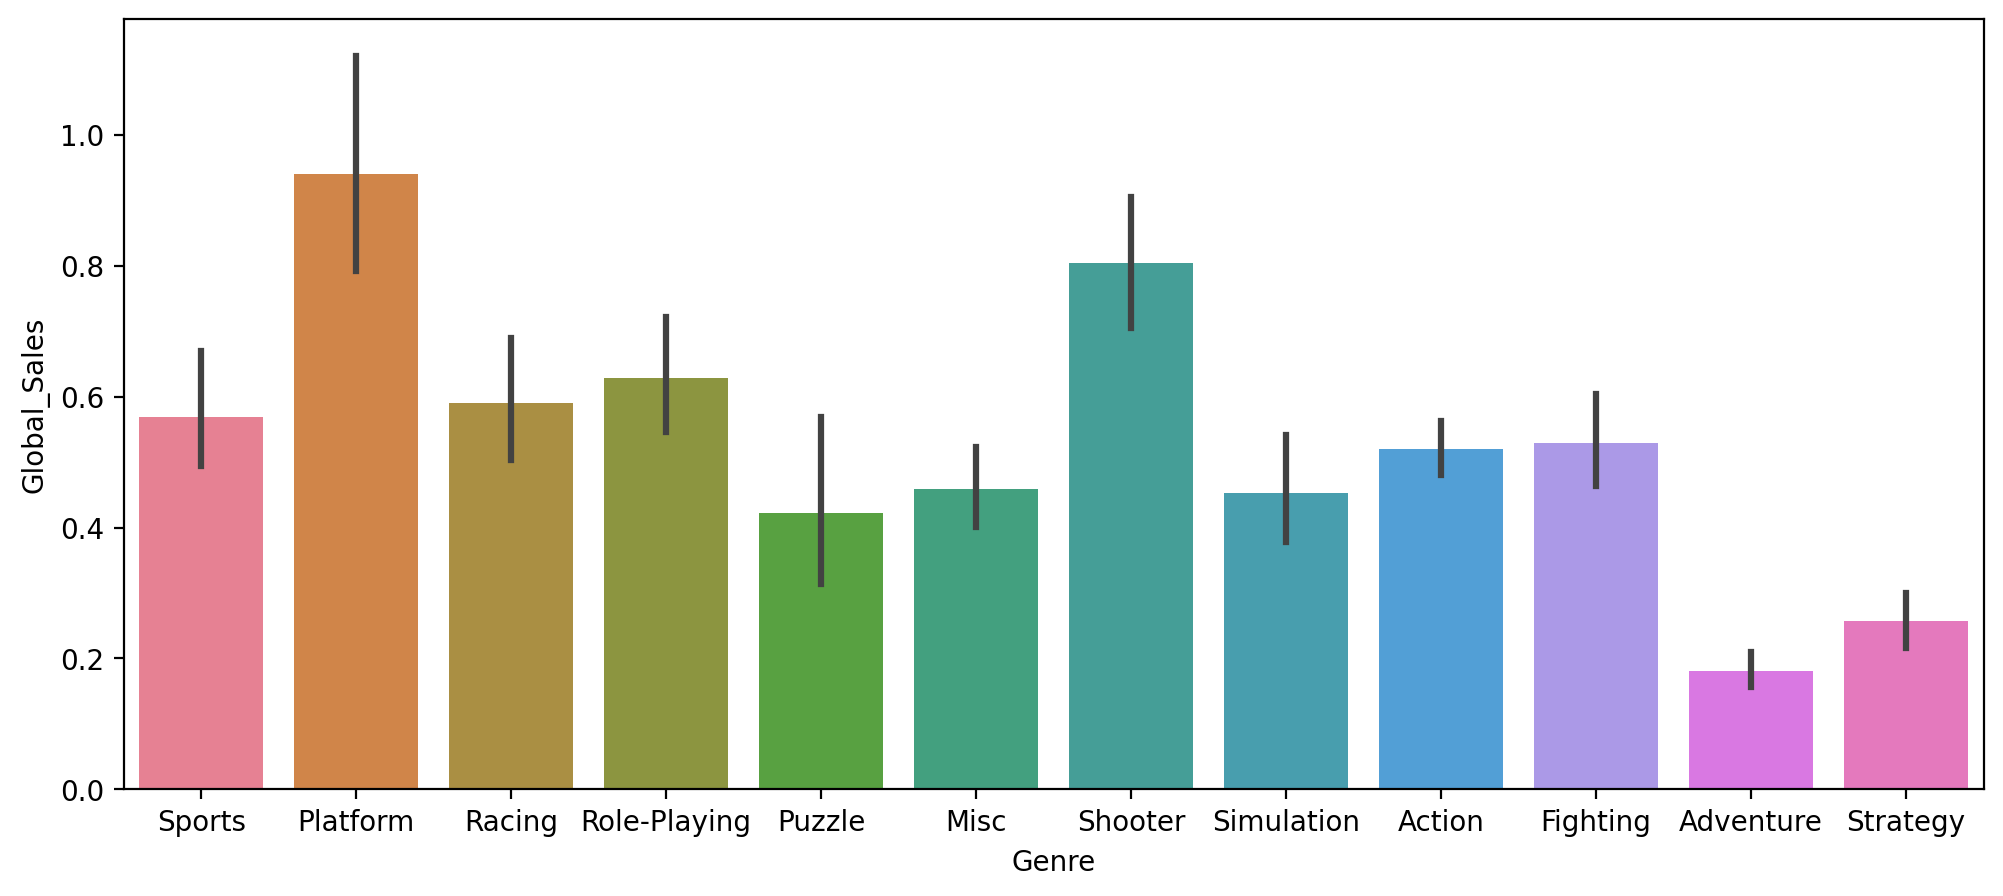

In [20]:
fig, ax = plt.subplots(figsize=(12,5), dpi=200)
ax = sns.barplot(df, x='Genre', y='Global_Sales', hue='Genre')

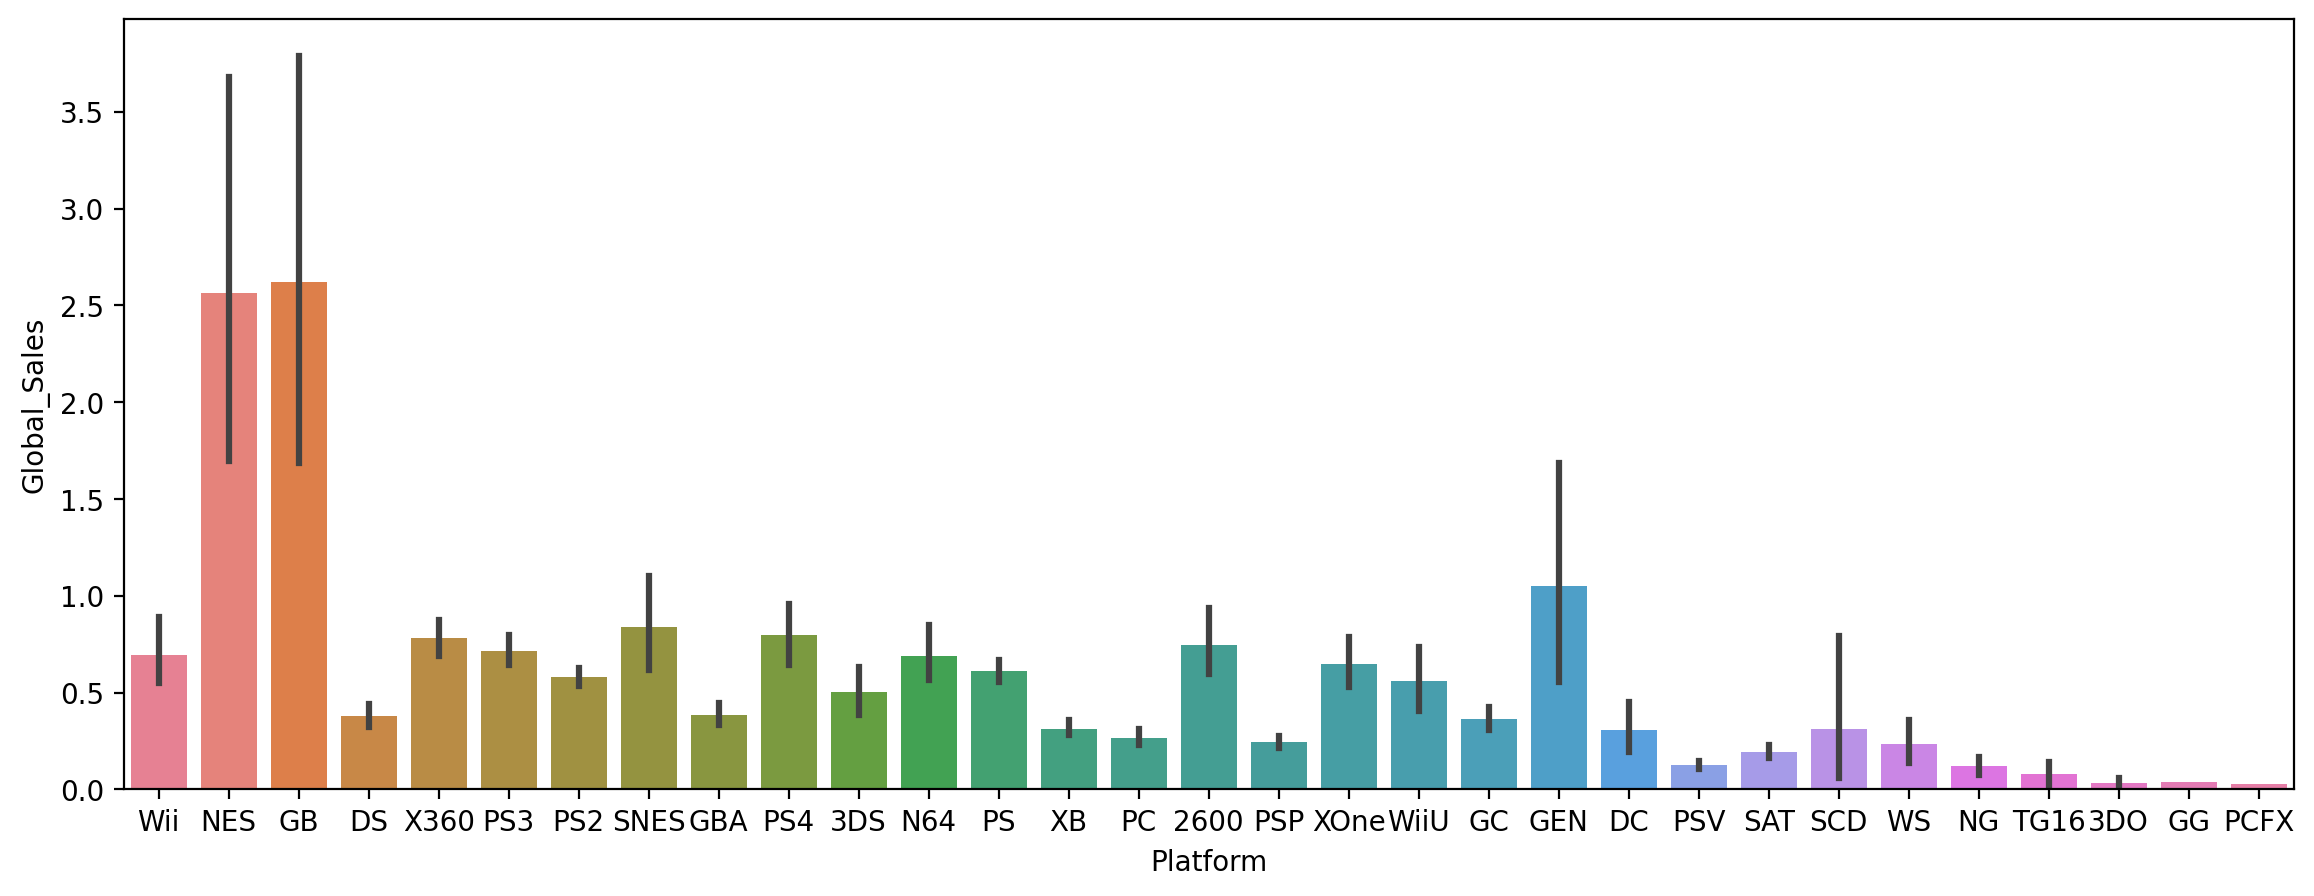

In [21]:
fig, ax = plt.subplots(figsize=(14,5), dpi=200)
ax = sns.barplot(df, x='Platform', y='Global_Sales', hue='Platform')

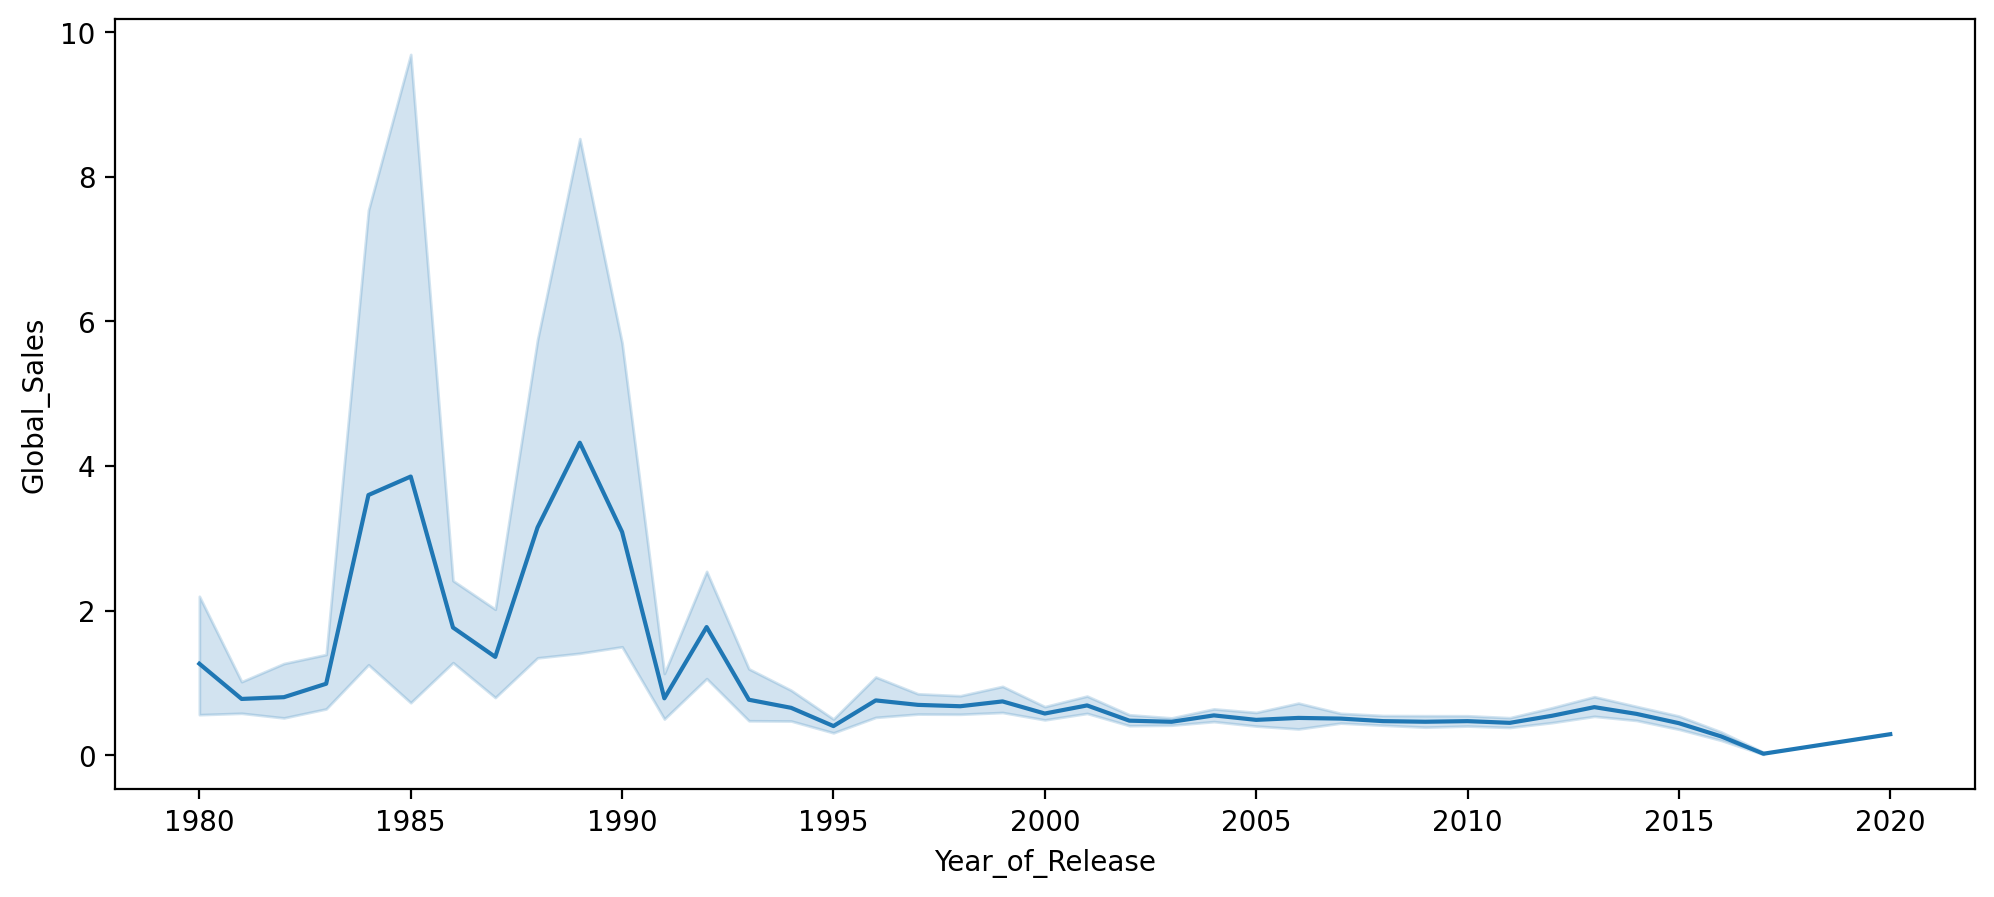

In [22]:
fig, ax = plt.subplots(figsize=(12,5), dpi=200)
ax = sns.lineplot(df, x='Year_of_Release', y='Global_Sales')

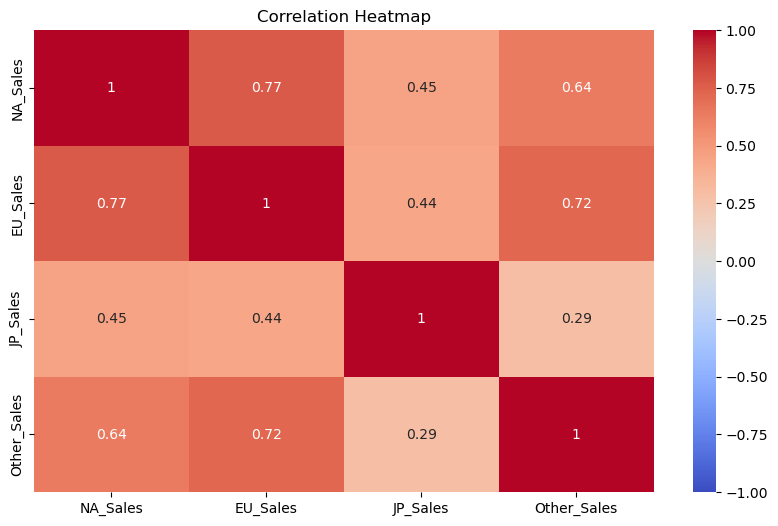

In [23]:
corr_matrix = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].corr()
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## Bivariate ratings focused

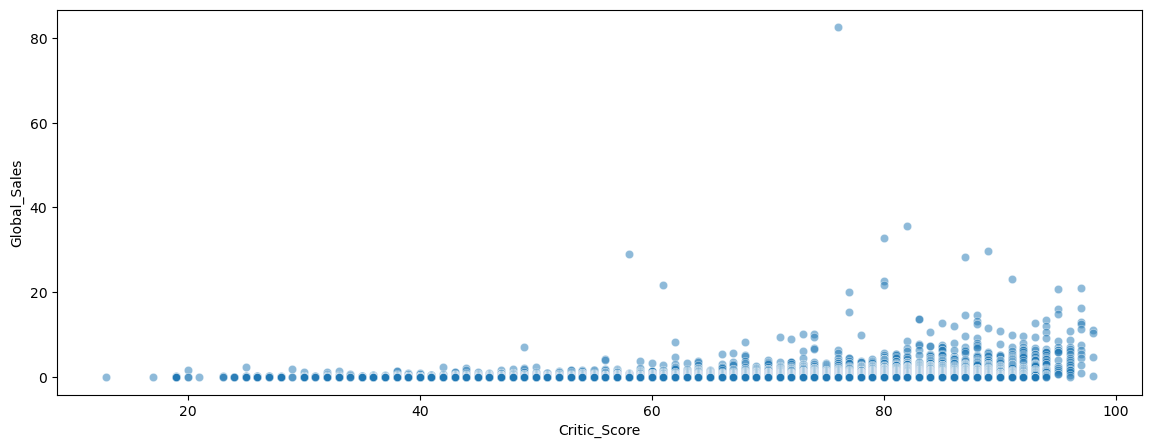

In [24]:
fig, ax = plt.subplots(figsize=(14,5))
sns.scatterplot(data=df_ratings, x='Critic_Score', y='Global_Sales', alpha=0.5)
plt.show()

In [25]:
df_ratings.nlargest(5, 'Global_Sales')

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,80.0,322.0,Nintendo,E
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,83.0,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,80.0,192.0,Nintendo,E
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,85.0,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,66.0,129.0,Nintendo,E


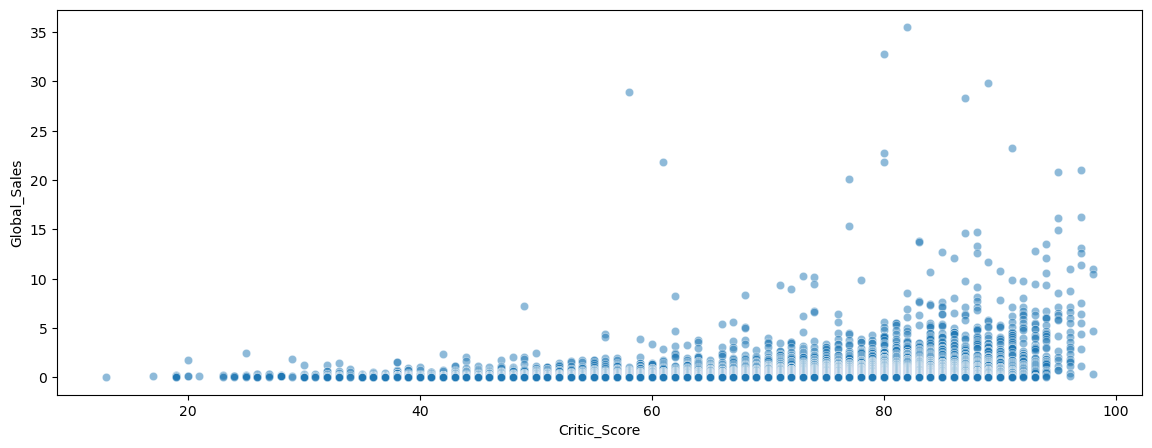

In [26]:
fig, ax = plt.subplots(figsize=(14,5))
df_no_outlier = df_ratings[df_ratings['Name'] != 'Wii Sports']
sns.scatterplot(data=df_no_outlier, x='Critic_Score', y='Global_Sales', alpha=0.5)
plt.show()

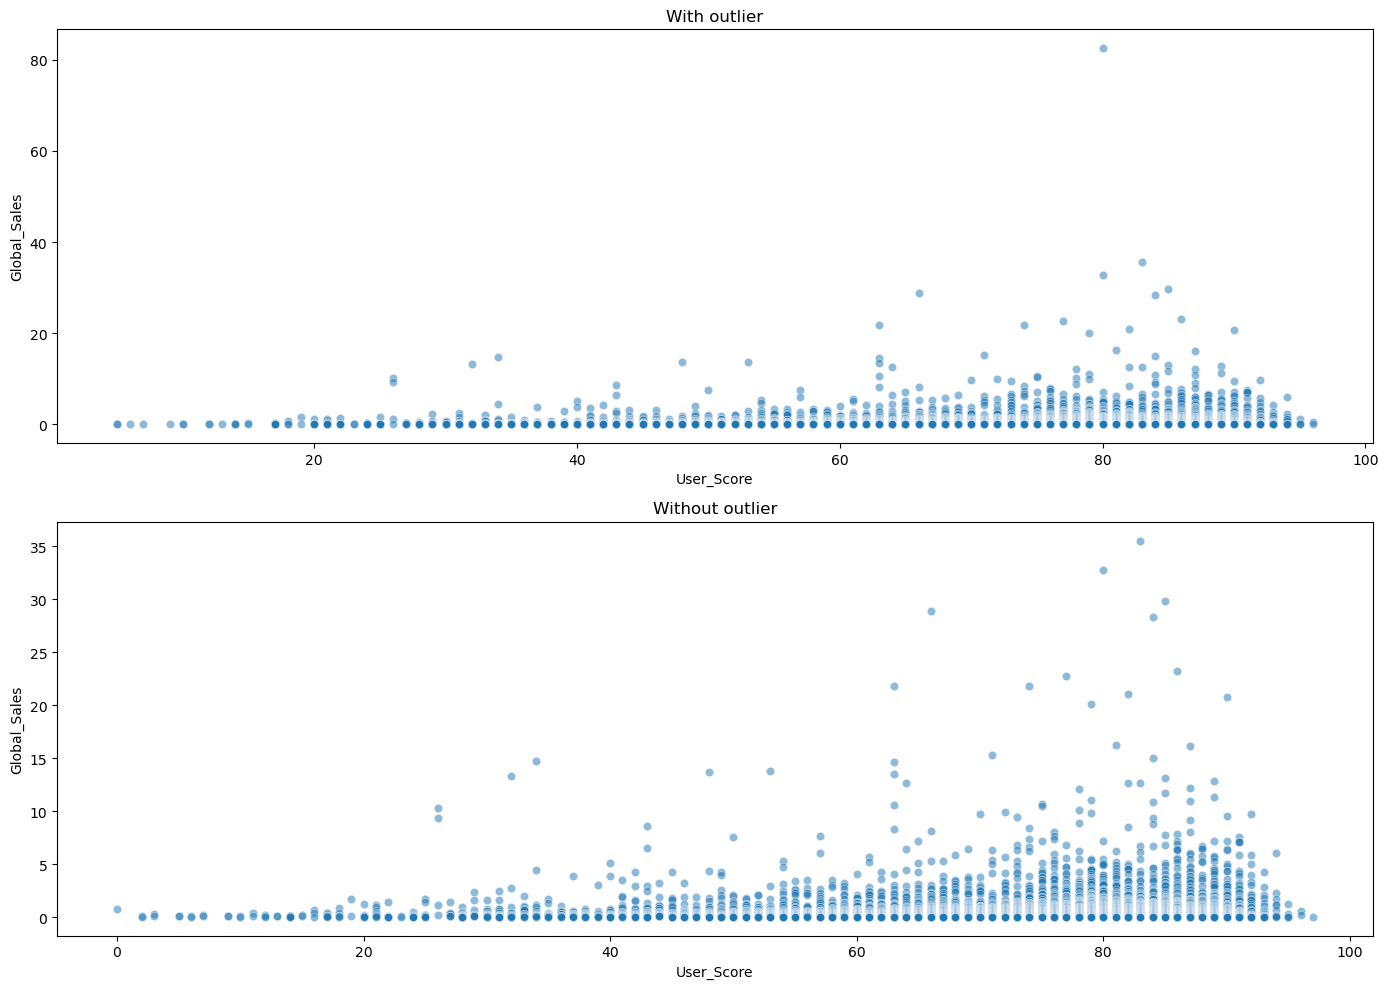

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(14,10))

sns.scatterplot(data=df_ratings, x='User_Score', y='Global_Sales', alpha=0.5, ax=ax[0])
ax[0].set_title('With outlier')

df_no_outlier = df[df['Name'] != 'Wii Sports']
sns.scatterplot(data=df_no_outlier, x='User_Score', y='Global_Sales', alpha=0.5, ax=ax[1])
ax[1].set_title('Without outlier')

plt.tight_layout()
plt.show()

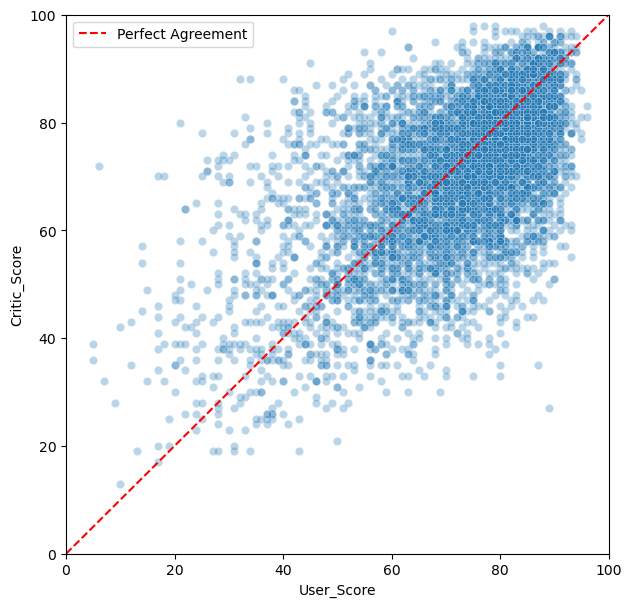

In [28]:
fig, ax = plt.subplots(figsize=(7,7))
sns.scatterplot(data=df_ratings, x='User_Score', y='Critic_Score', alpha=0.3, ax=ax)
ax.plot([0,100], [0,100], color='red', linestyle='--', label='Perfect Agreement')
ax.set_xlim(0,100)
ax.set_ylim(0,100)
ax.legend()
plt.show()

In [29]:
higher = (df_ratings['Critic_Score'] > df_ratings['User_Score']).mean() * 100
lower = (df_ratings['Critic_Score'] < df_ratings['User_Score']).mean() * 100
equal = (df_ratings['Critic_Score'] == df_ratings['User_Score']).mean() * 100

print(f'Critic higher: {higher:.2f}%')
print(f'User higher: {lower:.2f}%')
print(f'Equal: {equal:.2f}%')

Critic higher: 40.68%
User higher: 55.14%
Equal: 4.18%
